# Embedding filters 1 — Exponential moving average (EMA)

The workhorse for appearance/ReID embeddings. An EMA blend
``e <- rho * e + (1 - rho) * z`` is a steady-state scalar Kalman
filter: the gain ``(1 - rho)`` is constant rather than derived from a
covariance. It is cheap (``O(D)``), stable, and is what DeepSORT,
FairMOT and BoT-SORT use to smooth the per-track feature.

unitrack ships it as `EMAFuse` (the blend, an `Observation`) paired
with `EMATrack` (a no-op `Process`). Here we plug it into a real
`Tracker` and watch it denoise a drifting embedding.


In [1]:
import torch
import matplotlib.pyplot as plt

import unitrack
from unitrack.assignment import Associate, Jonker
from unitrack.costs import Cosine
from unitrack.data import Detections, FrameContext, TensorSpec
from unitrack.lifecycle import IncludeAll, NoLifecycle
from unitrack.pipeline import Pipe

torch.manual_seed(0)

D = 16          # embedding dimensionality (256+ in practice; 16 plots fast)
T = 44          # frames

def make_clip(noise=0.15, seed=0, switch=None):
    """
    A unit embedding that rotates slowly in the (e0, e1) plane plus
    per-frame noise in all D dims. Rotating in a known plane means
    projecting onto dims (0, 1) shows the true path as a circle arc.
    `switch` optionally rotates the plane mid-clip (an appearance change).
    """
    g = torch.Generator().manual_seed(seed)
    t = torch.arange(T).float()
    theta = 0.10 * t
    truth = torch.zeros(T, D)
    truth[:, 0] = torch.cos(theta)
    truth[:, 1] = torch.sin(theta)
    if switch is not None:
        # after `switch`, swap appearance into the (e2, e3) plane.
        truth[switch:, :] = 0.0
        truth[switch:, 2] = torch.cos(theta[switch:])
        truth[switch:, 3] = torch.sin(theta[switch:])
    obs = truth + noise * torch.randn(T, D, generator=g)
    obs = torch.nn.functional.normalize(obs, dim=-1)
    dets = [Detections(index=torch.tensor([0]), emb=obs[k:k + 1].clone(),
                       batch_size=[1]) for k in range(T)]
    return t, truth, obs, dets

def run(tracker, dets, fields=("emb",)):
    """Run a single-object clip through a real Tracker; collect snapshot fields."""
    ms = unitrack.MultiStream(tracker)
    rec = {f: [] for f in fields}
    for k, d in enumerate(dets):
        ctx = FrameContext.make(frame_idx=k, delta=1.0, fps=1.0, stream_key=0)
        res = ms.step(stream_key=0, detections=d, ctx=ctx)
        for f in fields:
            rec[f].append(getattr(res.snapshot, f)[0].clone())
    return {f: torch.stack(v) for f, v in rec.items()}

def cos_to_truth(est, truth):
    e = torch.nn.functional.normalize(est, dim=-1)
    u = torch.nn.functional.normalize(truth, dim=-1)
    return (e * u).sum(-1)

t, truth, obs, dets = make_clip()
print(f"clip: {T} frames, D={D}; raw-detection mean cosine-to-truth "
      f"= {cos_to_truth(obs, truth).mean():.3f}")


clip: 44 frames, D=16; raw-detection mean cosine-to-truth = 0.855


In [2]:
from unitrack.states import EMAFuse, EMATrack, FromDetectionField, State

def ema_tracker(rho):
    states = {
        "emb": State(
            schema=TensorSpec(shape=(D,), dtype=torch.float32),
            process=EMATrack("emb"),
            observation=EMAFuse("emb", rho=rho),
            init=FromDetectionField("emb"),
        ),
    }
    return unitrack.Tracker(
        root=Pipe(cost=Cosine("emb"), assoc=Associate(Jonker(threshold=0.6))),
        states=states, lifecycle=NoLifecycle(), visibility=IncludeAll(),
    )

rec = run(ema_tracker(rho=0.8), dets)


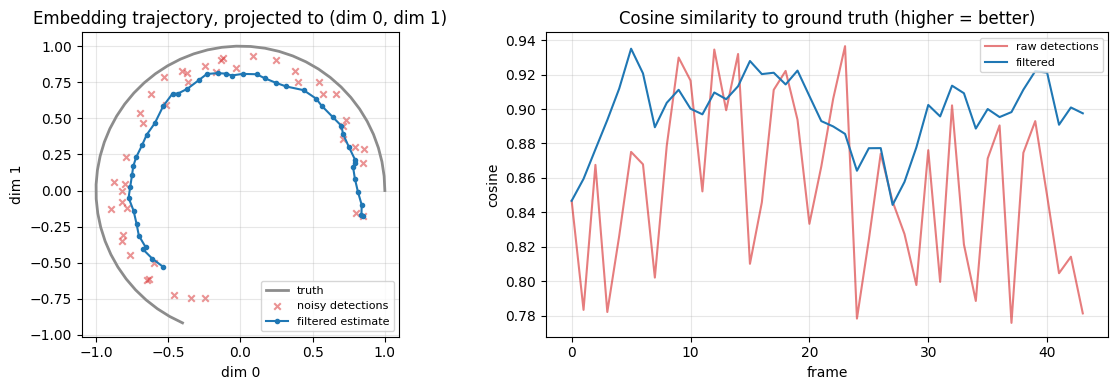

raw mean cos = 0.855   filtered mean cos = 0.898


In [3]:
fig, (axp, axc) = plt.subplots(1, 2, figsize=(12, 4))
axp.plot(truth[:, 0], truth[:, 1], "-", color="0.55", lw=2, label="truth")
axp.scatter(obs[:, 0], obs[:, 1], marker="x", color="tab:red", s=22,
            alpha=0.5, label="noisy detections")
axp.plot(rec["emb"][:, 0], rec["emb"][:, 1], "o-", color="tab:blue",
         ms=3, label="filtered estimate")
axp.set_title("Embedding trajectory, projected to (dim 0, dim 1)")
axp.set_xlabel("dim 0"); axp.set_ylabel("dim 1")
axp.legend(fontsize=8); axp.grid(alpha=0.3); axp.set_aspect("equal")

axc.plot(t, cos_to_truth(obs, truth), color="tab:red", alpha=0.6,
         label="raw detections")
axc.plot(t, cos_to_truth(rec["emb"], truth), color="tab:blue",
         label="filtered")
axc.set_title("Cosine similarity to ground truth (higher = better)")
axc.set_xlabel("frame"); axc.set_ylabel("cosine"); axc.legend(fontsize=8)
axc.grid(alpha=0.3)

plt.tight_layout(); plt.show()
print(f"raw mean cos = {cos_to_truth(obs, truth).mean():.3f}   "
      f"filtered mean cos = {cos_to_truth(rec['emb'], truth).mean():.3f}")


## The bias-variance knob

`rho` trades responsiveness for smoothness: high `rho` rejects noise
but lags the drift; low `rho` follows the drift but keeps more noise.
There is a sweet spot — the same trade a Kalman filter makes
automatically through its gain (next notebook).


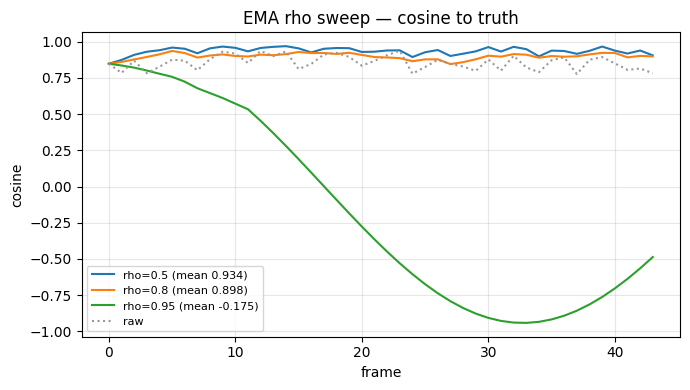

In [4]:
fig, ax = plt.subplots(figsize=(7, 4))
for rho in (0.5, 0.8, 0.95):
    r = run(ema_tracker(rho), dets)
    ax.plot(t, cos_to_truth(r["emb"], truth), label=f"rho={rho} "
            f"(mean {cos_to_truth(r['emb'], truth).mean():.3f})")
ax.plot(t, cos_to_truth(obs, truth), color="0.6", ls=":", label="raw")
ax.set_title("EMA rho sweep — cosine to truth")
ax.set_xlabel("frame"); ax.set_ylabel("cosine")
ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


**Takeaway.** EMA is the cheap, robust default. It carries no
uncertainty, so it cannot tell you *how sure* it is — for that, use a
Kalman / information / vMF filter (notebooks 2-4), or a gallery
(notebook 5) when one vector per track is too little memory.
